In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi
import Soccer_OCEL.utils as utils

from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types
import pm4py

from pm4py.algo.discovery.dfg.variants import clean_time
from pm4py.visualization.dfg.variants import timeline as timeline_gviz_generator
from pm4py.visualization.dfg import visualizer as dfg_visualizer

In [2]:
path='data/28196177'
games=get_games(path)
#games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
GD=[]
for Game in games:
    print(f'Getting {Game}')
    GameData=load_game_data(path, Game, pass_direction=True, event_based_possession=True)
    GameData=assign_roles_multi(GameData, team=True)
    #GameData = utils.formatting(GameData)
    #save
    with open(os.path.join('output','output_pkl',f"GameData_{Game}_WithPassDIR.pkl"), "wb") as f:
        pickle.dump(GameData, f)
    print(f'GameData of {Game} processed and saved')
    GD.append(GameData)
#allgame_df=pd.concat(all_games).sort_values('time:timestamp').reset_index(drop=True)

Getting J03WMX


/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/floodlight/core/events.py:80: UserWarning: The 'gameclock' column does not match the defined value range (from floodlight.core.definitions). This may lead to unexpected behavior of methods using this column.
  warnings.warn(


GameData of J03WMX processed and saved
Getting J03WN1
GameData of J03WN1 processed and saved
Getting J03WQQ
GameData of J03WQQ processed and saved
Getting J03WR9


/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/floodlight/core/events.py:80: UserWarning: The 'gameclock' column does not match the defined value range (from floodlight.core.definitions). This may lead to unexpected behavior of methods using this column.
  warnings.warn(


GameData of J03WR9 processed and saved
Getting J03WPY
GameData of J03WPY processed and saved
Getting J03WOH
GameData of J03WOH processed and saved
Getting J03WOY


/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/floodlight/core/events.py:80: UserWarning: The 'gameclock' column does not match the defined value range (from floodlight.core.definitions). This may lead to unexpected behavior of methods using this column.
  warnings.warn(


GameData of J03WOY processed and saved


In [9]:
GameData.events

,level_0,eID,gameclock,tID,pID,outcome,timestamp,minute,second,qualifier,...,playmaker_h,playmaker_a,playmaker,side,right_h,right_a,left_h,left_a,right,left
0,0,KickOff_Play_Pass,0.000,DFL-CLU-00000Q,DFL-OBJ-002FXA,1.0,2022-09-10 20:31:31.610000+02:00,0.0,0.0,"{'GameSection': 'firstHalf', 'TeamLeft': 'DFL-...",...,None,None,None,Unknown,None,None,None,None,None,None
1,0,Pass_Received,0.200,DFL-CLU-00000Q,DFL-OBJ-0025BB,1.0,2022-09-10 20:31:31.810000+02:00,0.0,0.0,"{'GameSection': 'firstHalf', 'TeamLeft': 'DFL-...",...,None,None,None,Unknown,None,None,None,None,None,None
2,1,Play_Pass,1.218,DFL-CLU-00000Q,DFL-OBJ-0025BB,0.0,2022-09-10 20:31:32.828000+02:00,0.0,1.0,"{'PlayAngle': '317.02', 'PenaltyBox': 'false',...",...,None,None,None,Unknown,None,None,None,None,None,None
3,1,Ball_lost,1.378,DFL-CLU-00000Q,DFL-OBJ-0025BB,0.0,2022-09-10 20:31:32.988000+02:00,0.0,1.0,"{'PlayAngle': '317.02', 'PenaltyBox': 'false',...",...,None,None,None,Unknown,None,None,None,None,None,None
4,1,Pass_Intercepted,1.418,DFL-CLU-00000P,DFL-OBJ-002GMO,0.0,2022-09-10 20:31:33.028000+02:00,0.0,1.0,"{'PlayAngle': '317.02', 'PenaltyBox': 'false',...",...,None,None,None,central,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,1185,Ball_lost,NaN,DFL-CLU-00000P,DFL-OBJ-J01KJ5,0.0,NaT,31.0,32.0,"{'PlayAngle': '62.82', 'PenaltyBox': 'true', '...",...,None,None,None,left,None,None,DFL-OBJ-J01KJ5,None,None,DFL-OBJ-J01KJ5
2473,1197,Ball_lost,NaN,DFL-CLU-00000Q,DFL-OBJ-0025BB,0.0,NaT,33.0,9.0,"{'PlayAngle': '350.22', 'PenaltyBox': 'false',...",...,None,None,None,Unknown,None,None,None,None,None,None
2474,1201,Ball_lost,NaN,DFL-CLU-00000P,DFL-OBJ-J0130T,0.0,NaT,33.0,37.0,"{'PlayAngle': '326.79', 'PenaltyBox': 'false',...",...,None,None,None,left,None,None,DFL-OBJ-J0130T,None,None,DFL-OBJ-J0130T
2475,1363,Ball_lost,NaN,DFL-CLU-00000Q,DFL-OBJ-0028JQ,0.0,NaT,45.0,25.0,"{'PlayAngle': '159.31', 'PenaltyBox': 'false',...",...,None,None,None,central,None,None,None,None,None,None


In [7]:
#load all
path='data/28196177'
#games=get_games(path)
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}_simplified_teamed_epos.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
    all_games.append(GD_loaded.events)
allgame_df=pd.concat(all_games).sort_values('time:timestamp').reset_index(drop=True)

In [ ]:
games=['J03WQQ'], 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}_simplified_teamed_epos.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
    df= GD_loaded.events
    df['pteam'] = df['Player'].apply(lambda pid: utils.get_teamside_from_pID(pid, GD_loaded.team_sheets_df) if pd.notnull(pid) else None)
    all_games.append(df)
allgame_df=pd.concat(all_games).sort_values('time:timestamp').reset_index(drop=True)

In [29]:
diff_rows = allgame_df[(allgame_df["pteam"] != allgame_df["team"])&(~allgame_df['tID'].isna())]
diff_rows[['case:concept:name','tID','Player','pteam','team']]

,case:concept:name,tID,Player,pteam,team
0,J03WOH_Away_1,DFL-CLU-000011,DFL-OBJ-002GAB,Away,NaN
25,J03WOH_Away_1,DFL-CLU-000011,DFL-OBJ-00268T,Away,NaN
30,J03WOH_Away_1,DFL-CLU-000011,DFL-OBJ-002G2Y,Away,NaN
38,J03WOH_Away_1,DFL-CLU-000011,DFL-OBJ-002G2Y,Away,NaN
40,J03WOH_Away_1,DFL-CLU-000011,DFL-OBJ-0027XP,Away,NaN
...,...,...,...,...,...
21659,J03WR9_Away_228,DFL-CLU-00000I,DFL-OBJ-0028G2,Away,NaN
21660,J03WR9_Away_228,DFL-CLU-00000I,DFL-OBJ-002GPI,Away,NaN
21661,J03WR9_Away_228,DFL-CLU-00000P,DFL-OBJ-J01KJ5,Home,NaN
21678,J03WR9_Away_229,DFL-CLU-00000I,DFL-OBJ-00017G,Away,NaN


In [27]:
#games=['J03WQQ']#, 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
# games=['J03WR9']#, 'J03WPY']#Fortuna Düsseldorf lost game
# all_games=[]
# for Game in games:
#     with open(os.path.join('output','output_pkl',f"GameData_{Game}_simplified_teamed_epos.pkl"), "rb") as f:
#         GD_loaded = pickle.load(f)
GD_loaded.team_sheets_df#.query('tID=="DFL-OBJ-00017G"')

,player,position,team,jID,pID,tID,Home_Away
0,A. Bodzek,None,Fortuna Düsseldorf,13,DFL-OBJ-00005H,DFL-CLU-00000P,Home
1,R. Hennings,STL,Fortuna Düsseldorf,28,DFL-OBJ-00008K,DFL-CLU-00000P,Home
2,R. Wolf,None,Fortuna Düsseldorf,1,DFL-OBJ-000170,DFL-CLU-00000P,Home
3,Matthias Zimmermann,RV,Fortuna Düsseldorf,25,DFL-OBJ-0000NZ,DFL-CLU-00000P,Home
4,A. Hoffmann,None,Fortuna Düsseldorf,3,DFL-OBJ-00006V,DFL-CLU-00000P,Home
5,F. Klaus,ORM,Fortuna Düsseldorf,11,DFL-OBJ-0000F8,DFL-CLU-00000P,Home
6,Jorrit Hendrix,DML,Fortuna Düsseldorf,29,DFL-OBJ-J0130T,DFL-CLU-00000P,Home
7,M. Sobottka,DMR,Fortuna Düsseldorf,31,DFL-OBJ-00028V,DFL-CLU-00000P,Home
8,Dawid Kownacki,STR,Fortuna Düsseldorf,9,DFL-OBJ-002FXT,DFL-CLU-00000P,Home
9,E. Iyoha,OLM,Fortuna Düsseldorf,19,DFL-OBJ-0026RH,DFL-CLU-00000P,Home


In [4]:
from pm4py.statistics.start_activities.log import get as start_get
from pm4py.statistics.end_activities.log import get as end_get
event_log = pm4py.convert_to_event_log(allgame_df)
start_activities = start_get.get_start_activities(event_log)
#end_activities = end_get.get_end_activities(event_log)
start_activities#, end_activities


{'Pass': 13,
 'Holding Central Defensive First': 7,
 'Pass_Intercepted': 379,
 'BallClaiming': 100,
 'TacklingGame': 101,
 'Wing Transition': 7,
 'PenaltyNotAwarded': 8,
 'Holding Wing Attack Third': 2,
 'Cross_Intercepted': 55,
 'Lateral Repositioning': 7,
 'Central Retreat': 5,
 'OtherBallAction': 15,
 'Wing Retreat': 1,
 'Central Transition': 5,
 'Penalty_ShotAtGoal': 1,
 'Holding Wing Defensive First': 4,
 'Holding Central Attack Third': 4,
 'SpectacularPlay': 1,
 'Wing Advance': 1,
 'Holding Wing Midfield': 3,
 'FreeKick_ShotAtGoal': 2,
 'Diagonal Repositioning': 1,
 'ThrowIn': 1,
 'Holding Central Midfield': 3}

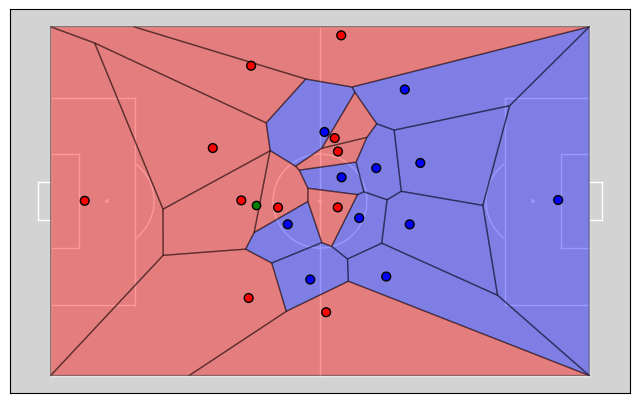

In [31]:
frame_voronoi_plot(GameData.positions, GameData.pitch, frame=22, session=1)
#save_voronoi_frames(GameData.positions, GameData.pitch, session=1, out_dir=f"{Game}_session1_step10", step=10)
#make_animation_from_frames(out_dir="frames_session1_step100", output="voronoi_session1.gif", fps=6)

In [8]:
allgame_df=utils.add_pass_cross_sequences(allgame_df)

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/utils.py:226: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_action = df['concept:name'].str.contains(r'(pass|cross)', case=False, na=False)
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/utils.py:227: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_excluded = df['concept:name'].str.contains(r'(received|intercepted)', case=False, na=False)


In [9]:
shot_events=allgame_df[(allgame_df['concept:name'].str.contains('Shot'))
                       &allgame_df['attribute:team'].str.contains('Home')
                       &(allgame_df['attribute:outcome']==0)
                         ]
shot_df = allgame_df[allgame_df['case:concept:name'].isin(shot_events['case:concept:name'])]
# end=shot_df[(shot_df['concept:name'].str.contains('Wide'))
#                           ]
# shot_df = shot_df[shot_df['case:concept:name'].isin(end['case:concept:name'])]
shot_df=utils.filter_players_involved_with_ball(shot_df)

event_log = pm4py.convert_to_event_log(shot_df)

In [12]:
# map pID -> team side using utils.get_teamside_from_pID
# support GD as object or list of GameData
# _team_sheets = None
# if hasattr(GD, "team_sheets_df"):
#     _team_sheets = GD.team_sheets_df
# elif isinstance(GD, (list, tuple)) and len(GD) > 0 and hasattr(GD[0], "team_sheets_df"):
#     _team_sheets = GD[0].team_sheets_df
# else:
#     raise RuntimeError("Could not find team_sheets_df on GD (expected GD.team_sheets_df or GD[0].team_sheets_df)")

shot_df['pteam'] = shot_df['Player'].apply(lambda pid: utils.get_teamside_from_pID(pid, GD.team_sheets_df) if pd.notnull(pid) else None)

NameError: name 'GD' is not defined

In [89]:
#log = shot_df[~shot_df['Forward'].isna()]
#log = shot_df[~shot_df['Midfielder'].isna()]
#log = shot_df[~shot_df['Defender'].isna()]
log = shot_df[~shot_df['Goalkeeper'].isna()]
#log=shot_df
dfg, start_act, end_act = pm4py.discover_dfg_typed(log)
dfg_time = clean_time.apply(log, parameters={"aggregation": "mean"})
gviz = timeline_gviz_generator.apply(dfg, dfg_time, parameters={"format": "png", "start_activities": start_act,
                                                                    "end_activities": end_act})
dfg_visualizer.view(gviz)

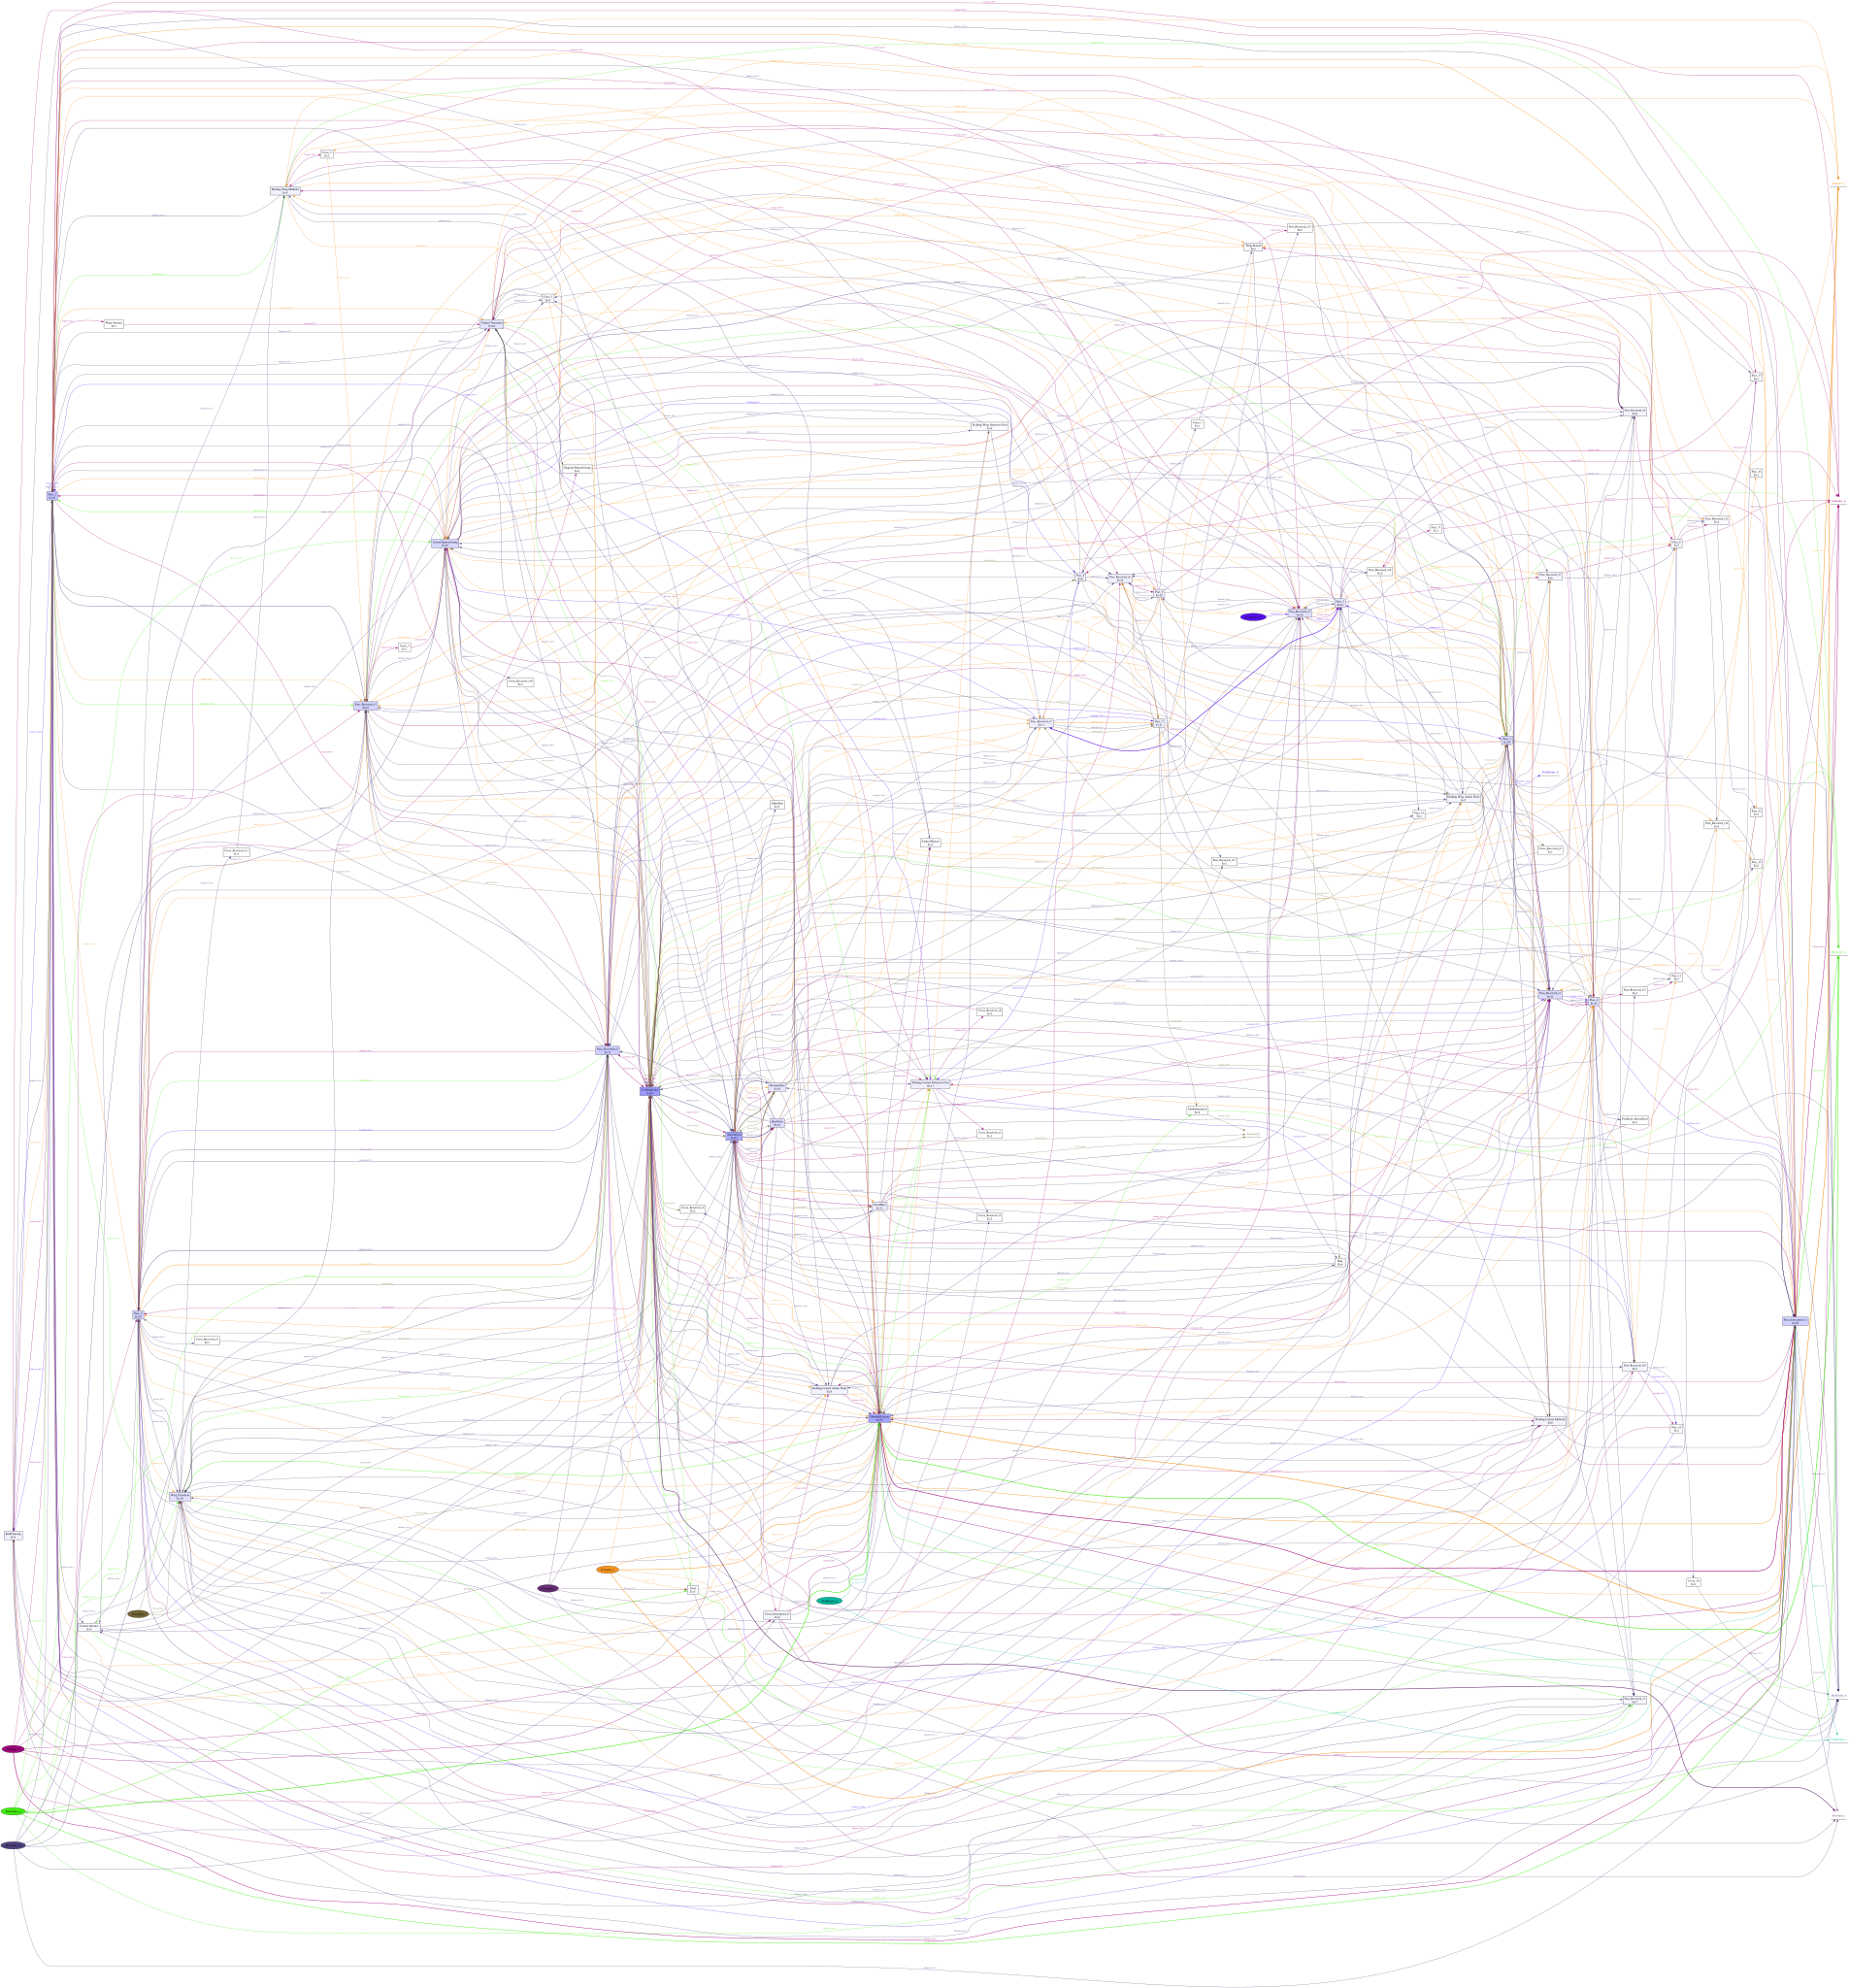

In [10]:
# convert to ocel
ocel= log_to_ocel_multiple_obj_types(event_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                     #'attacking_team', 'defending_team'
                                                     #'ball',
                                                     "Forward_h", "Midfielder_h", "Defender_h", "Goalkeeper_h"
                                                     ,"Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                     #,'Team','Player','Session', 'case:concept:name'
                                                     ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
dfg=pm4py.ocel.discover_ocdfg(ocel,business_hours=True)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

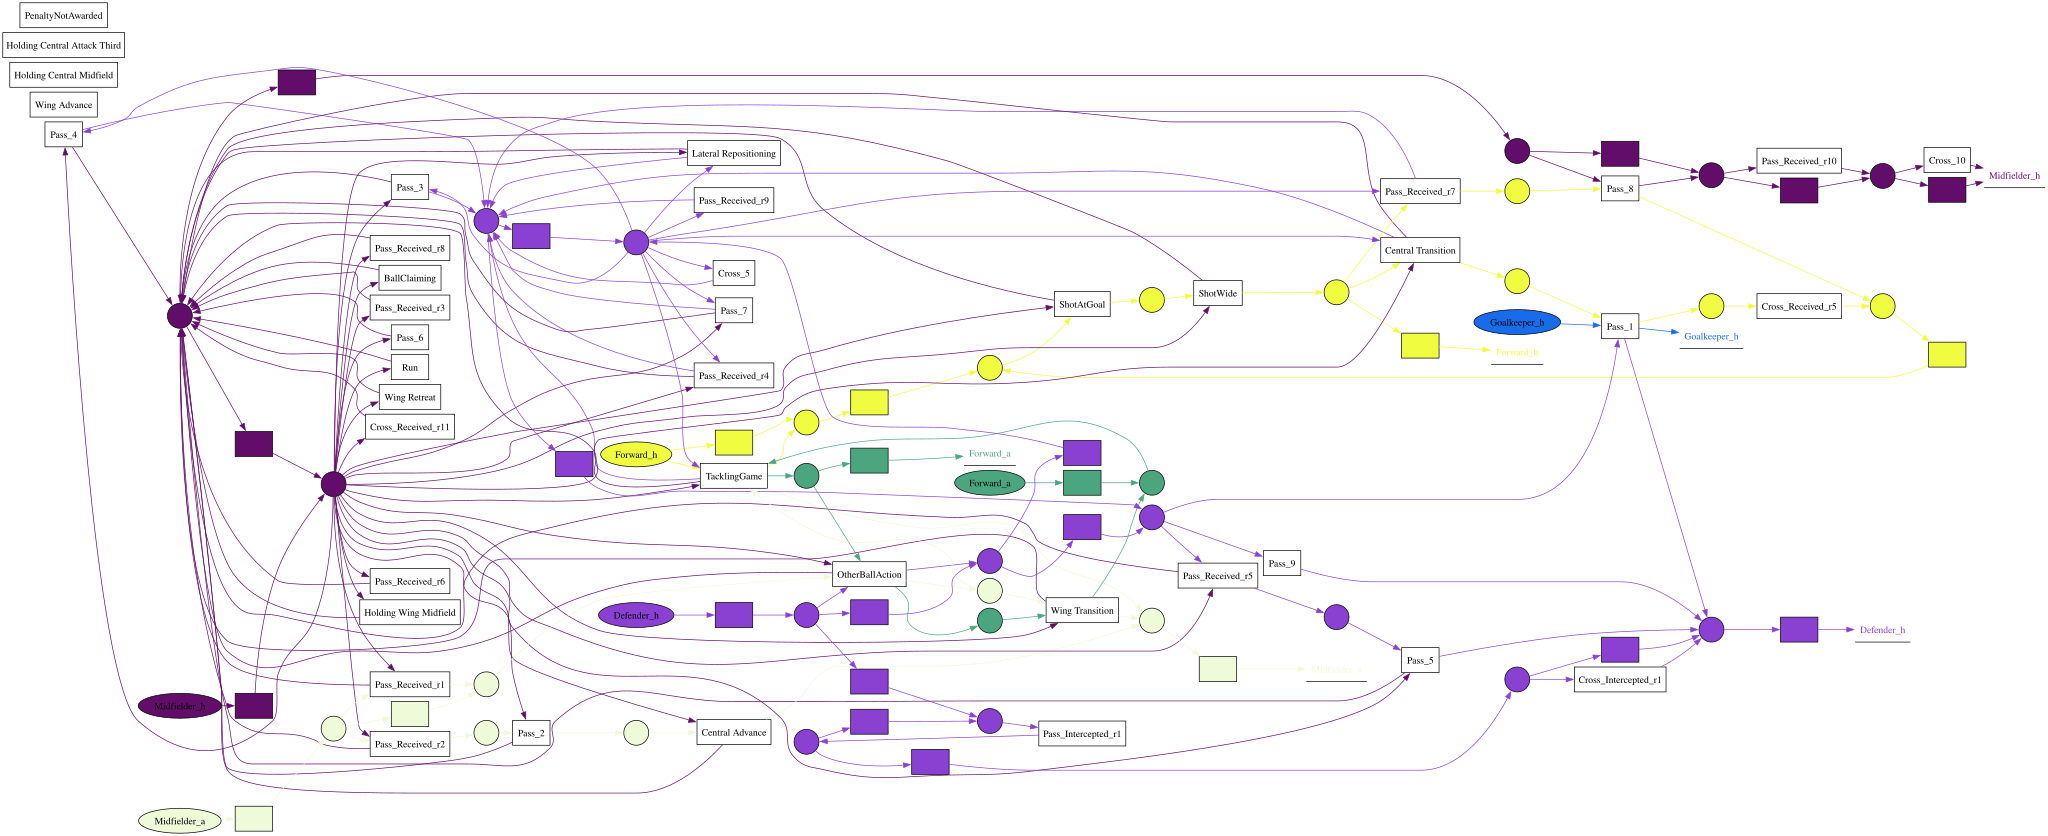

In [90]:
pn=pm4py.ocel.discover_oc_petri_net(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(pn)